In [1]:
import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, normalize_samples, sample_forward_process, get_best_params, smooth_parameters, interpolate_parameters
from physical_diffusion_fns.learning_fns import setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity, plot_parameter_as_fn_of_time
from physical_diffusion_fns.network_fns import setup_duffing_network_with_external_force_energy_fn, setup_overdamped_SDE, solve_SDE  

jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


# Setup Problem

### Generate samples from a Gaussian mixture - the target distribution

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.7, .3])

# Define means
means = 2+jnp.array([
    [1., .5],   # mean of first Gaussian
    [-1., -.5],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.01, 0.0],    # covariance of first Gaussian
        [0.0, 0.01]],
    [[0.01, 0.0],   # covariance of second Gaussian
        [0.0, 0.01]],
])
# Generate samples
samples_raw = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
normalize = False
if normalize:
    samples_target, mean, std = normalize_samples(samples_raw)
else:
    mean_data = 0.
    std_data = 1.
    samples_target = (samples_raw-mean_data)/std_data
    

x_range = jnp.linspace(-10, 10, 100)  # Example range from -5 to 5

### Plot samples and marginal of target distributions

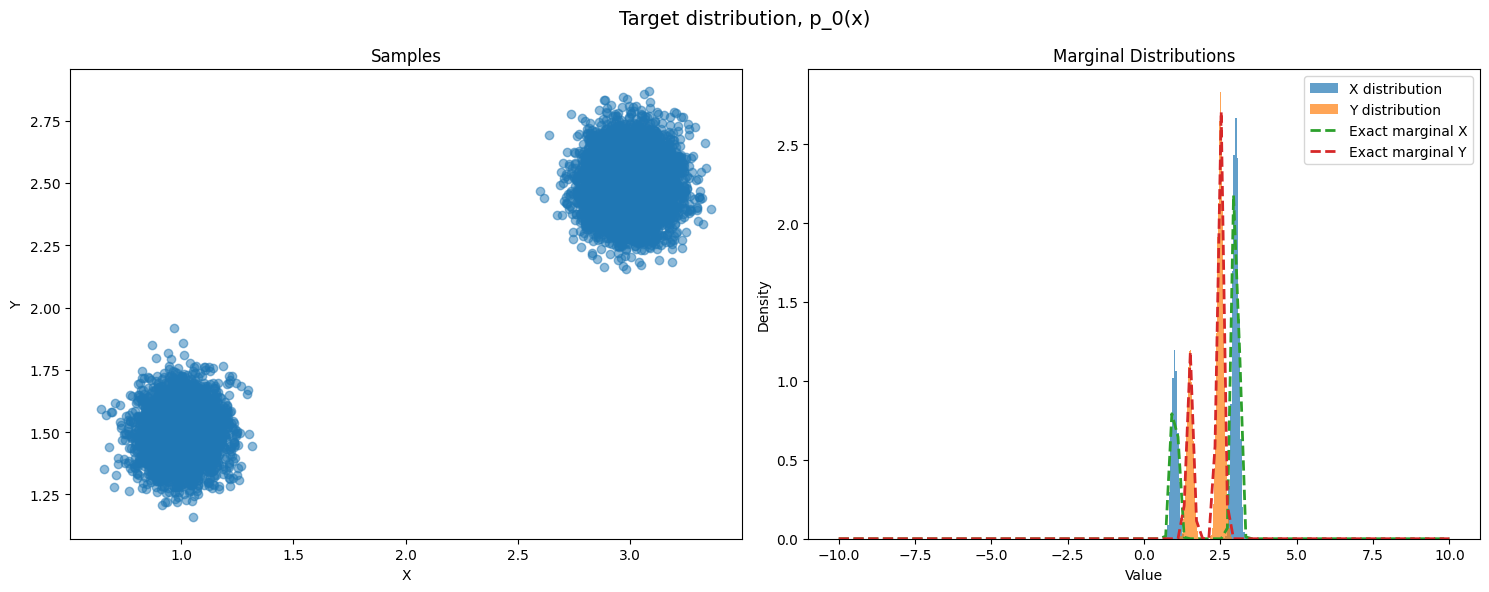

In [3]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_target[:, 0], samples_target[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_raw[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_raw[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
for dim in range(2):
    marginal = jnp.zeros_like(x_range)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x_range - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x_range, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Network size and topology

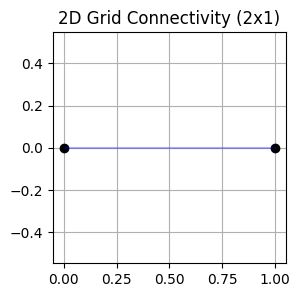

In [4]:
N_osc = 2
connectivity = jnp.array([[0, 1]])
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

### Setup initial params 

In [5]:
k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 0.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
bias_0 = jnp.array([0.,0.,])
params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0, bias_0)
params_names = ["k_lin", "k_duff", "c_lin", "c_optomech", "external_force"]
params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
constraint_indices = jnp.arange(N_osc,2*N_osc)

### Build energy

In [6]:
energy_fn = setup_duffing_network_with_external_force_energy_fn(connectivity, unflatten)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


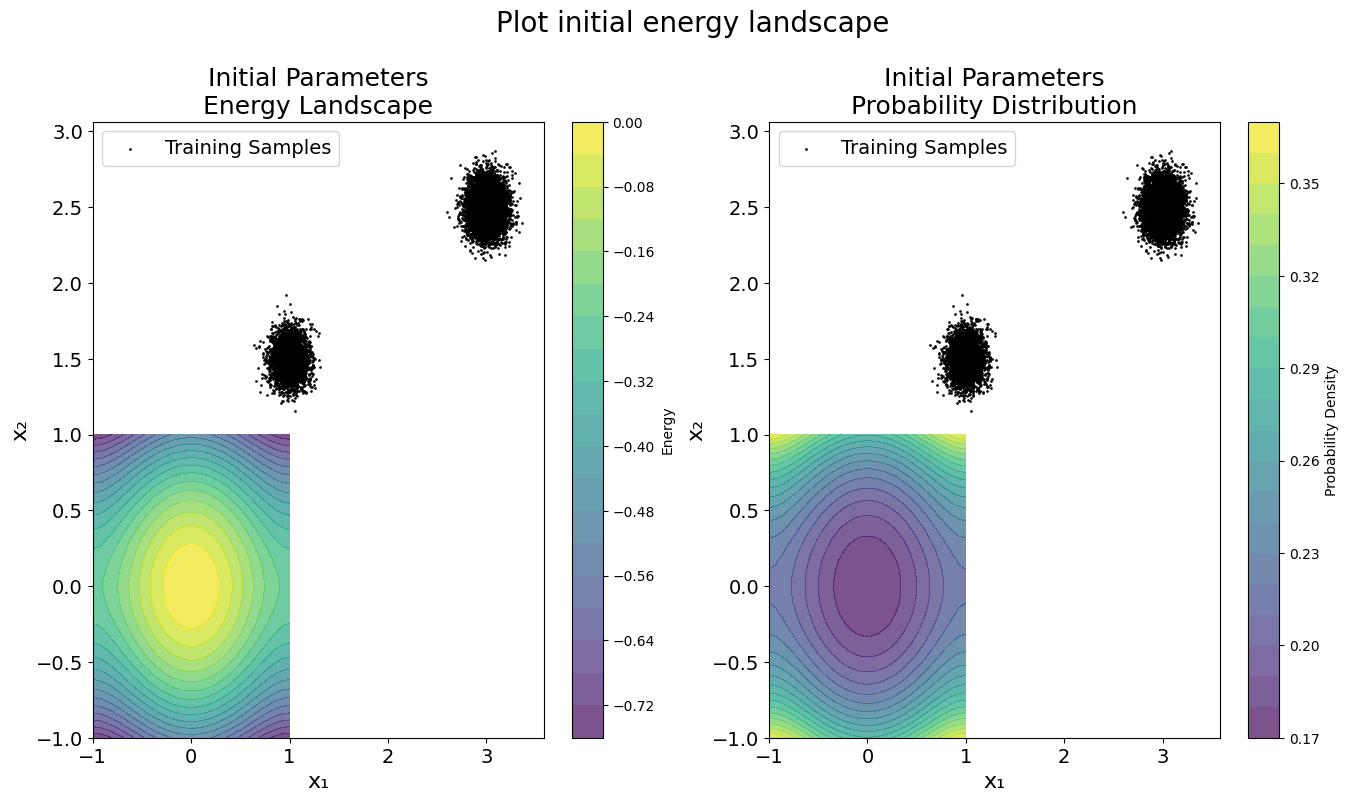

In [7]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_target,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape" 
)

# Learning

In [8]:
# Choose training method
training_method = "SM"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)

# Setup loss and gradient functions based on selected method
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "CD1":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch: -CD1_gradient(energy_fn, batch, flattened_args, dt=0.001, D=1, key=key, num_noise_samples=1000)
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")

#### Optimization parameters and filenames

In [9]:
# Forward process parameters
n_time_steps = 100
t_forward = 1.0
sigma_forward = 0.5
forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-9), jnp.log(t_forward), n_time_steps))
forward_time_pts = forward_time_pts.at[0].set(0.)

# Optimization parameters
learning_rate = .01
n_epochs = 100000//2
batch_size = 2*128
window_size=1000
tolerance=1e-16
patience=50


In [10]:
comment = "with_external_force"
optimization_folder = (f"{training_method}_"
           f"t_forward_{t_forward}_"
           f"n_timesteps_{n_time_steps}_"
           f"lr_{learning_rate}_"
           f"epochs_{n_epochs}_"
           f"batch_{batch_size}_"
           f"window_{window_size}_"
           f"tol_{tolerance}_"
           f"patience_{patience}_"
           f"{comment}")

In [11]:
# Setup output directories
base_dir = "out/problems"
problem_type_folder = "mixture_gaussians_sampling"
problem_folder = f"weights_{weights}_means_{means.flatten()}_covs_{covs.flatten()}"  # Replace with your actual parameters

output_dir = os.path.join(base_dir, problem_type_folder, problem_folder,optimization_folder)

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)

### Print final distribution of the forward

Saving figure to out/problems/mixture_gaussians_sampling/weights_[0.7 0.3]_means_[3.  2.5 1.  1.5]_covs_[0.01 0.   0.   0.01 0.01 0.   0.   0.01]/SM_t_forward_1.0_n_timesteps_100_lr_0.01_epochs_50000_batch_256_window_1000_tol_1e-16_patience_50_with_external_force


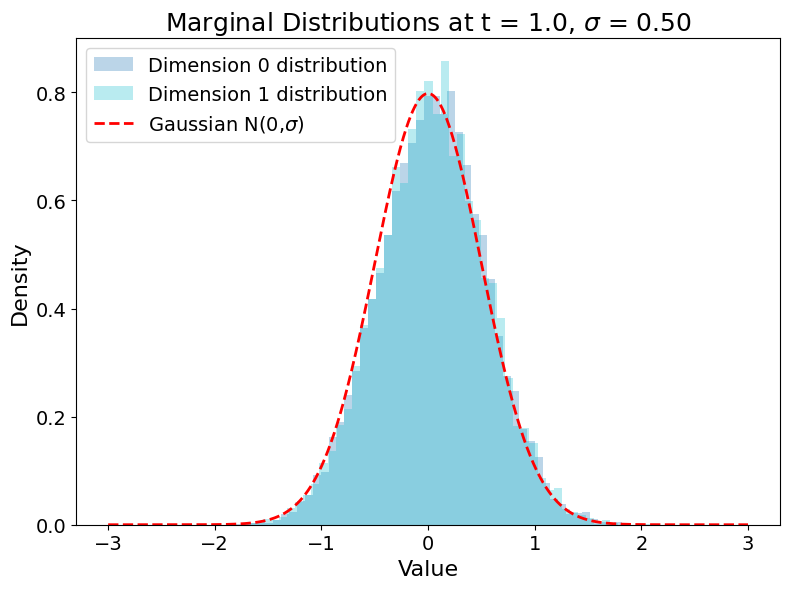

In [12]:
key, subkey = jr.split(key)
samples_t = sample_forward_process(t_forward, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_target, key=subkey)
plot_forward_marginals(samples_t, t_forward, sigma_forward, beta=1.0, path=output_dir, save_fig=True, fontsize=16)

Optimization for time 0.0
Epoch 0 - Loss: 176.9318
Epoch 100 - Loss: -9.7151
Epoch 200 - Loss: -13.4729
Epoch 300 - Loss: -17.1760
Epoch 400 - Loss: -19.4371
Epoch 500 - Loss: -26.3239
Epoch 600 - Loss: -24.1283
Epoch 700 - Loss: -30.9370
Epoch 800 - Loss: -33.4194
Epoch 900 - Loss: -29.5467
Epoch 1000 - Loss: -34.3096
Epoch 1100 - Loss: -36.5140
Epoch 1200 - Loss: -39.7486
Epoch 1300 - Loss: -39.7361
Epoch 1400 - Loss: -38.5730
Epoch 1500 - Loss: -44.0422
Epoch 1600 - Loss: -43.4560
Epoch 1700 - Loss: -48.5068
Epoch 1800 - Loss: -44.3997
Epoch 1900 - Loss: -46.4932
Epoch 2000 - Loss: -47.3847
Epoch 2100 - Loss: -40.8250
Epoch 2200 - Loss: -49.8635
Epoch 2300 - Loss: -55.4997
Epoch 2400 - Loss: -42.0905
Epoch 2500 - Loss: -45.5293
Epoch 2600 - Loss: -52.5134
Epoch 2700 - Loss: -55.2460
Epoch 2800 - Loss: -56.0681
Epoch 2900 - Loss: -49.3438
Epoch 3000 - Loss: -56.9860
Epoch 3100 - Loss: -54.9573
Epoch 3200 - Loss: -53.9497
Epoch 3300 - Loss: -55.5828
Epoch 3400 - Loss: -47.7940
Epoch 3

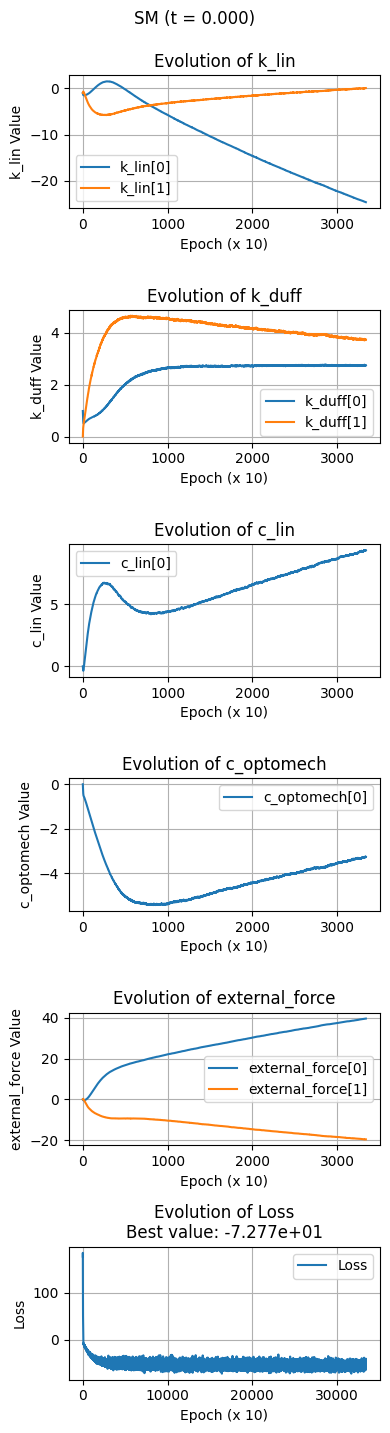

Optimization for time 1.2328467394420664e-09
Epoch 0 - Loss: -52.6402
Epoch 100 - Loss: -59.7546
Epoch 200 - Loss: -58.4735
Epoch 300 - Loss: -53.8860
Epoch 400 - Loss: -47.5983
Epoch 500 - Loss: -48.3394
Epoch 600 - Loss: -51.9259
Epoch 700 - Loss: -60.3656
Epoch 800 - Loss: -59.0877
Epoch 900 - Loss: -64.0097
Epoch 1000 - Loss: -47.6020
Epoch 1100 - Loss: -56.2168
Epoch 1200 - Loss: -57.9491
Epoch 1300 - Loss: -59.4186
Epoch 1400 - Loss: -60.6452
Epoch 1500 - Loss: -53.3379
Epoch 1600 - Loss: -58.9122
Epoch 1700 - Loss: -53.7154
Epoch 1800 - Loss: -50.3634
Epoch 1900 - Loss: -61.2108
Epoch 2000 - Loss: -51.2696
Epoch 2100 - Loss: -54.7560
Epoch 2200 - Loss: -48.6783
Epoch 2300 - Loss: -53.2604
Epoch 2400 - Loss: -54.2931
Epoch 2500 - Loss: -62.7365
Epoch 2600 - Loss: -54.4108
Epoch 2700 - Loss: -61.9220
Epoch 2800 - Loss: -53.8179
Epoch 2900 - Loss: -44.3391
Epoch 3000 - Loss: -50.3824
Epoch 3100 - Loss: -50.2719
Epoch 3200 - Loss: -58.6023
Epoch 3300 - Loss: -58.7580
Epoch 3400 - Lo

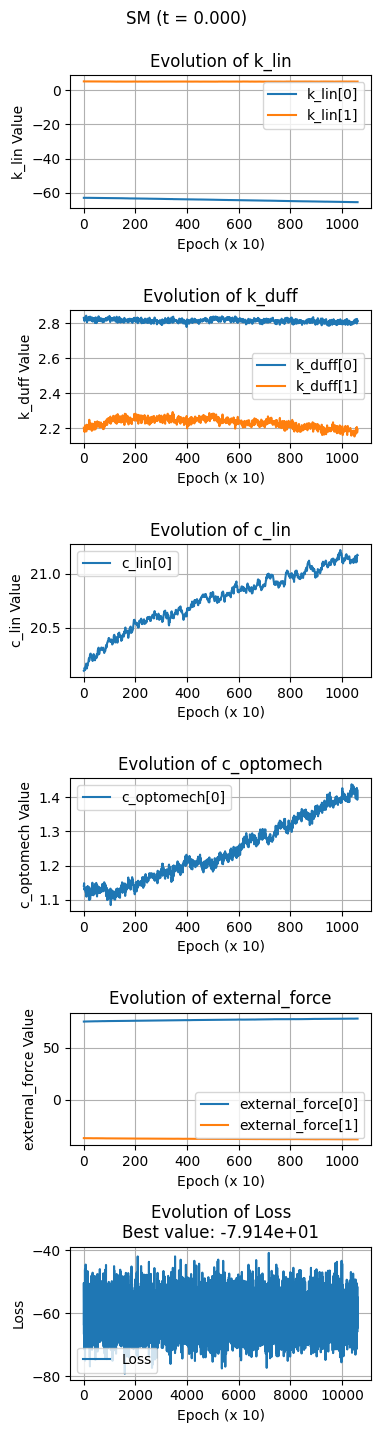

Optimization for time 1.0000000000000018e-08
Epoch 0 - Loss: -55.2876
Epoch 100 - Loss: -56.9323
Epoch 200 - Loss: -68.7131
Epoch 300 - Loss: -65.9863
Epoch 400 - Loss: -62.7652
Epoch 500 - Loss: -64.7288
Epoch 600 - Loss: -57.4293
Epoch 700 - Loss: -63.2043
Epoch 800 - Loss: -65.9474
Epoch 900 - Loss: -66.1228
Epoch 1000 - Loss: -61.8507
Epoch 1100 - Loss: -56.8435
Epoch 1200 - Loss: -61.6132
Epoch 1300 - Loss: -56.5236
Epoch 1400 - Loss: -56.7910
Epoch 1500 - Loss: -58.8874
Epoch 1600 - Loss: -60.1732
Epoch 1700 - Loss: -64.4336
Epoch 1800 - Loss: -66.7322
Epoch 1900 - Loss: -65.0645
Epoch 2000 - Loss: -62.0029
Epoch 2100 - Loss: -59.5243
Epoch 2200 - Loss: -68.1771
Epoch 2300 - Loss: -56.8340
Epoch 2400 - Loss: -61.5473
Epoch 2500 - Loss: -64.6552
Epoch 2600 - Loss: -60.6059
Epoch 2700 - Loss: -66.4077
Epoch 2800 - Loss: -64.4503
Epoch 2900 - Loss: -53.7642
Epoch 3000 - Loss: -52.8241
Epoch 3100 - Loss: -59.6486
Epoch 3200 - Loss: -55.0750
Epoch 3300 - Loss: -61.6138
Epoch 3400 - Lo

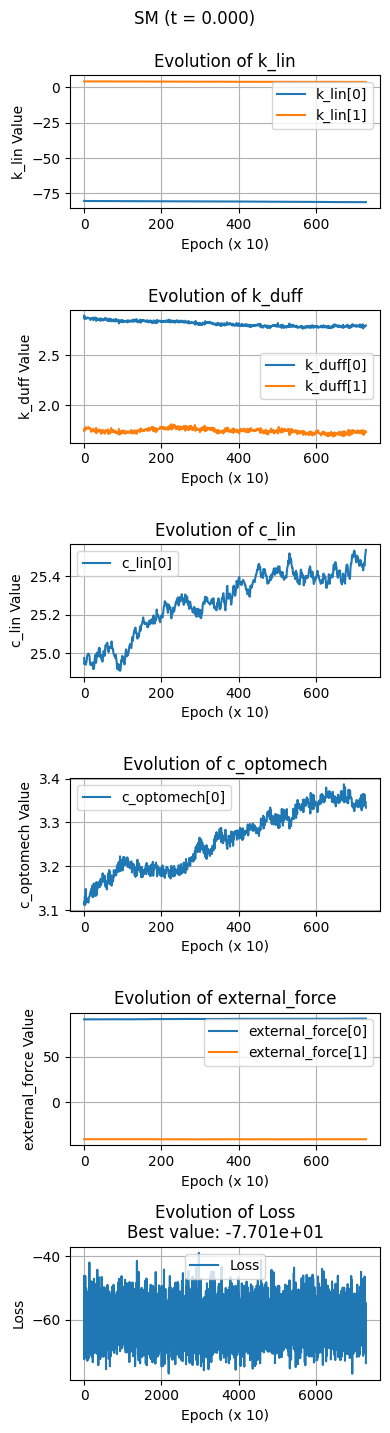

Optimization for time 8.11130830789687e-08
Epoch 0 - Loss: -53.1749
Epoch 100 - Loss: -64.6289
Epoch 200 - Loss: -62.7193
Epoch 300 - Loss: -55.9921
Epoch 400 - Loss: -61.1759
Epoch 500 - Loss: -62.6987
Epoch 600 - Loss: -64.5662
Epoch 700 - Loss: -58.5402
Epoch 800 - Loss: -56.7069
Epoch 900 - Loss: -56.1335
Epoch 1000 - Loss: -66.9617
Epoch 1100 - Loss: -49.9496
Epoch 1200 - Loss: -55.2250
Epoch 1300 - Loss: -53.7366
Epoch 1400 - Loss: -66.3269
Epoch 1500 - Loss: -64.7282
Epoch 1600 - Loss: -62.7348
Epoch 1700 - Loss: -53.5505
Epoch 1800 - Loss: -55.5437
Epoch 1900 - Loss: -65.9975
Epoch 2000 - Loss: -61.0367
Epoch 2100 - Loss: -54.9301
Epoch 2200 - Loss: -56.8230
Epoch 2300 - Loss: -58.4704
Epoch 2400 - Loss: -62.9094
Epoch 2500 - Loss: -63.7906
Epoch 2600 - Loss: -58.3199
Epoch 2700 - Loss: -63.4115
Epoch 2800 - Loss: -64.5482
Epoch 2900 - Loss: -59.4083
Epoch 3000 - Loss: -58.7169
Epoch 3100 - Loss: -66.1743
Epoch 3200 - Loss: -62.2208
Epoch 3300 - Loss: -59.6360
Epoch 3400 - Loss

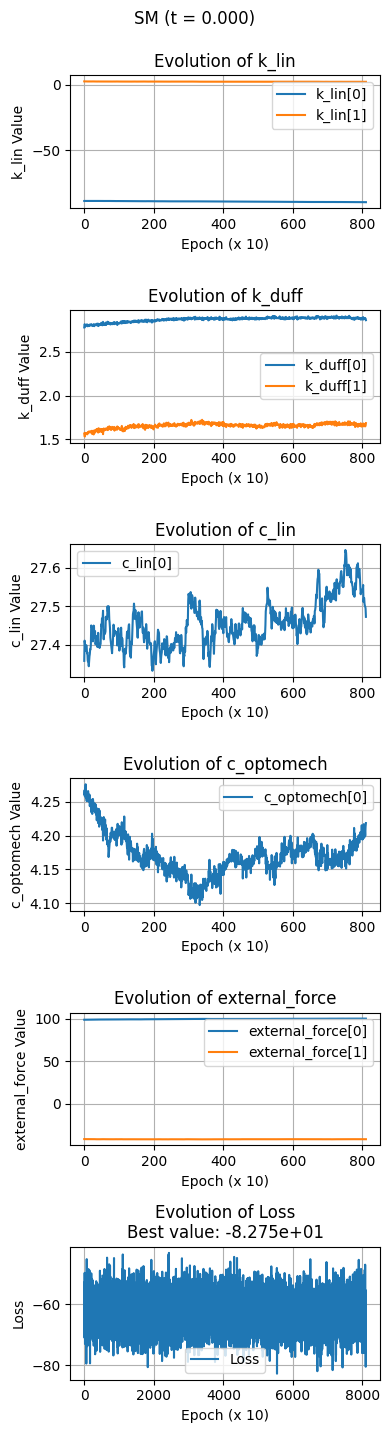

Optimization for time 6.57933224657569e-07
Epoch 0 - Loss: -58.2765
Epoch 100 - Loss: -66.4684
Epoch 200 - Loss: -58.1086
Epoch 300 - Loss: -59.0569
Epoch 400 - Loss: -64.5923
Epoch 500 - Loss: -56.6639
Epoch 600 - Loss: -61.1477
Epoch 700 - Loss: -70.9743
Epoch 800 - Loss: -55.3424
Epoch 900 - Loss: -63.1835
Epoch 1000 - Loss: -58.7622
Epoch 1100 - Loss: -64.1460
Epoch 1200 - Loss: -54.6051
Epoch 1300 - Loss: -63.2733
Epoch 1400 - Loss: -67.5204
Epoch 1500 - Loss: -68.8724
Epoch 1600 - Loss: -50.7594
Epoch 1700 - Loss: -56.0064
Epoch 1800 - Loss: -61.1956
Epoch 1900 - Loss: -57.5361
Epoch 2000 - Loss: -54.6724
Epoch 2100 - Loss: -58.1314
Epoch 2200 - Loss: -57.2495
Epoch 2300 - Loss: -59.5506
Epoch 2400 - Loss: -54.3953
Epoch 2500 - Loss: -52.6456
Epoch 2600 - Loss: -73.9749
Epoch 2700 - Loss: -65.5500
Epoch 2800 - Loss: -56.3321
Epoch 2900 - Loss: -54.9020
Epoch 3000 - Loss: -63.1831
Epoch 3100 - Loss: -60.9019
Epoch 3200 - Loss: -58.8289
Epoch 3300 - Loss: -64.7131
Epoch 3400 - Loss

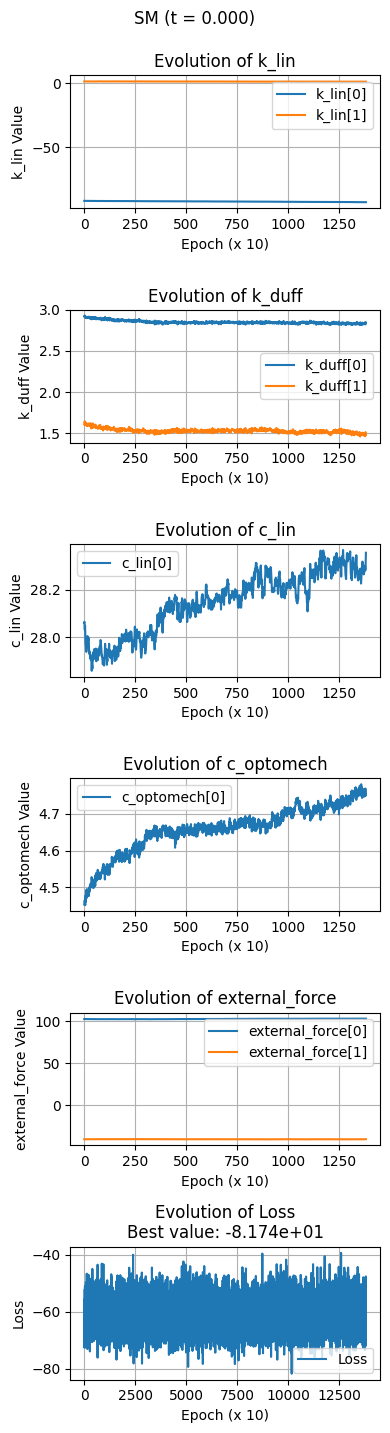

Optimization for time 5.336699231206308e-06
Epoch 0 - Loss: -59.8853
Epoch 100 - Loss: -66.8799
Epoch 200 - Loss: -59.6231
Epoch 300 - Loss: -59.6649
Epoch 400 - Loss: -64.5857
Epoch 500 - Loss: -54.0072
Epoch 600 - Loss: -55.0961
Epoch 700 - Loss: -61.2904
Epoch 800 - Loss: -60.7081
Epoch 900 - Loss: -64.3741
Epoch 1000 - Loss: -67.6300
Epoch 1100 - Loss: -65.3928
Epoch 1200 - Loss: -58.3315
Epoch 1300 - Loss: -60.9405
Epoch 1400 - Loss: -61.8346
Epoch 1500 - Loss: -60.0995
Epoch 1600 - Loss: -58.4021
Epoch 1700 - Loss: -49.3551
Epoch 1800 - Loss: -61.9122
Epoch 1900 - Loss: -64.5247
Epoch 2000 - Loss: -54.6560
Epoch 2100 - Loss: -60.8923
Epoch 2200 - Loss: -61.1368
Epoch 2300 - Loss: -61.7131
Epoch 2400 - Loss: -69.8872
Epoch 2500 - Loss: -58.5756
Epoch 2600 - Loss: -70.2393
Epoch 2700 - Loss: -71.0363
Epoch 2800 - Loss: -58.7037
Epoch 2900 - Loss: -66.0122
Epoch 3000 - Loss: -53.8069
Epoch 3100 - Loss: -54.8238
Epoch 3200 - Loss: -56.7543
Epoch 3300 - Loss: -73.7432
Epoch 3400 - Los

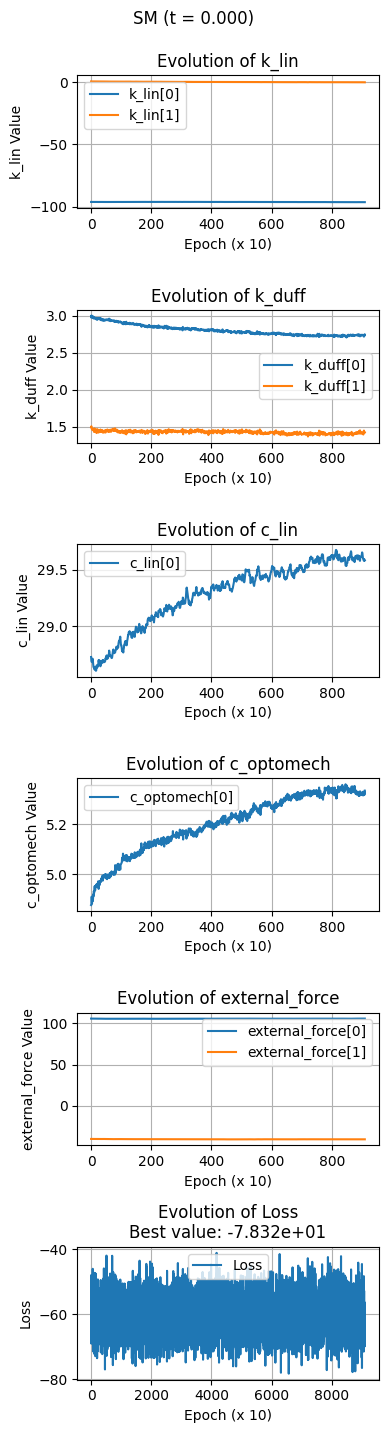

Optimization for time 4.328761281083064e-05
Epoch 0 - Loss: -51.2393
Epoch 100 - Loss: -63.7049
Epoch 200 - Loss: -65.9038
Epoch 300 - Loss: -56.8967
Epoch 400 - Loss: -60.9737
Epoch 500 - Loss: -51.9324
Epoch 600 - Loss: -64.1561
Epoch 700 - Loss: -60.2292
Epoch 800 - Loss: -69.8880
Epoch 900 - Loss: -67.9932
Epoch 1000 - Loss: -63.2641
Epoch 1100 - Loss: -64.7478
Epoch 1200 - Loss: -52.7603
Epoch 1300 - Loss: -62.8478
Epoch 1400 - Loss: -63.5198
Epoch 1500 - Loss: -72.6831
Epoch 1600 - Loss: -63.6026
Epoch 1700 - Loss: -63.5958
Epoch 1800 - Loss: -75.0696
Epoch 1900 - Loss: -66.1016
Epoch 2000 - Loss: -69.2046
Epoch 2100 - Loss: -66.6458
Epoch 2200 - Loss: -53.5107
Epoch 2300 - Loss: -59.5704
Epoch 2400 - Loss: -57.3181
Epoch 2500 - Loss: -62.9947
Epoch 2600 - Loss: -57.5504
Epoch 2700 - Loss: -66.1707
Epoch 2800 - Loss: -68.4018
Epoch 2900 - Loss: -63.3408
Epoch 3000 - Loss: -63.2660
Epoch 3100 - Loss: -56.4705
Epoch 3200 - Loss: -59.9941
Epoch 3300 - Loss: -59.1744
Epoch 3400 - Los

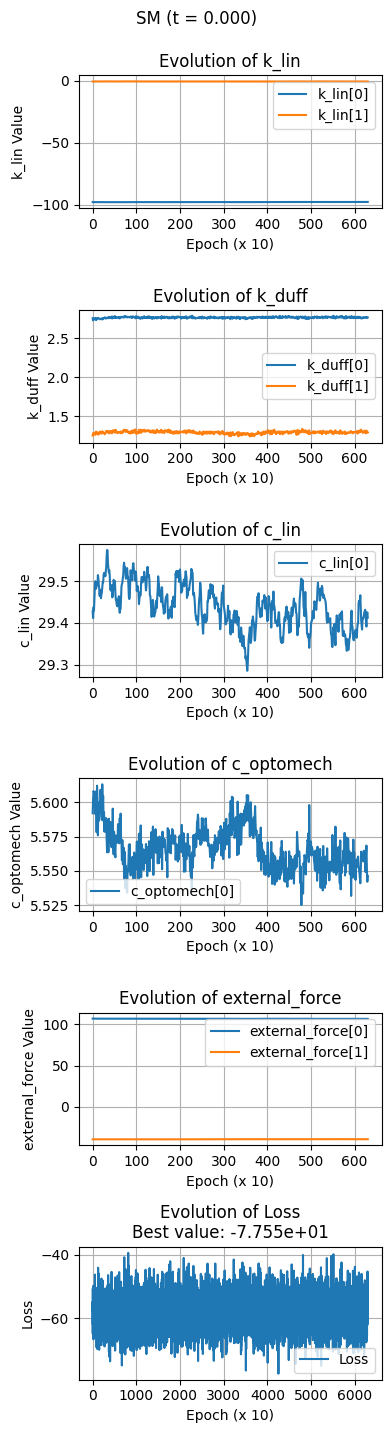

Optimization for time 0.00035111917342151353
Epoch 0 - Loss: -58.3964
Epoch 100 - Loss: -52.9571
Epoch 200 - Loss: -53.1040
Epoch 300 - Loss: -57.6014
Epoch 400 - Loss: -48.5163
Epoch 500 - Loss: -60.3594
Epoch 600 - Loss: -61.8424
Epoch 700 - Loss: -57.6473
Epoch 800 - Loss: -65.1153
Epoch 900 - Loss: -64.0517
Epoch 1000 - Loss: -57.0763
Epoch 1100 - Loss: -58.3847
Epoch 1200 - Loss: -63.8928
Epoch 1300 - Loss: -52.1949
Epoch 1400 - Loss: -55.5177
Epoch 1500 - Loss: -65.3244
Epoch 1600 - Loss: -56.3543
Epoch 1700 - Loss: -62.1403
Epoch 1800 - Loss: -55.2635
Epoch 1900 - Loss: -58.5218
Epoch 2000 - Loss: -52.7559
Epoch 2100 - Loss: -57.2352
Epoch 2200 - Loss: -65.6547
Epoch 2300 - Loss: -57.9027
Epoch 2400 - Loss: -58.1140
Epoch 2500 - Loss: -53.1315
Epoch 2600 - Loss: -52.3373
Epoch 2700 - Loss: -54.6578
Epoch 2800 - Loss: -52.6768
Epoch 2900 - Loss: -52.8576
Epoch 3000 - Loss: -59.2577
Epoch 3100 - Loss: -55.6128
Epoch 3200 - Loss: -57.1426
Epoch 3300 - Loss: -57.4444
Epoch 3400 - Lo

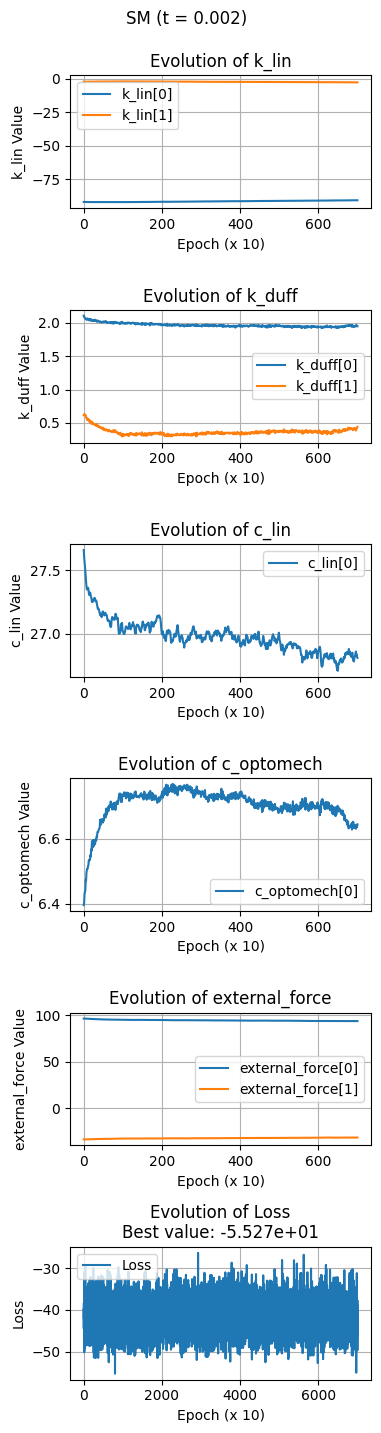

Optimization for time 0.0028480358684358073
Epoch 0 - Loss: -38.3128
Epoch 100 - Loss: -42.7231
Epoch 200 - Loss: -44.9026
Epoch 300 - Loss: -40.1666
Epoch 400 - Loss: -44.3703
Epoch 500 - Loss: -47.0120
Epoch 600 - Loss: -45.5412
Epoch 700 - Loss: -41.7423
Epoch 800 - Loss: -39.0315
Epoch 900 - Loss: -38.2209
Epoch 1000 - Loss: -41.6041
Epoch 1100 - Loss: -44.7928
Epoch 1200 - Loss: -41.1372
Epoch 1300 - Loss: -42.7489
Epoch 1400 - Loss: -32.5353
Epoch 1500 - Loss: -41.1158
Epoch 1600 - Loss: -40.0012
Epoch 1700 - Loss: -44.0522
Epoch 1800 - Loss: -41.3989
Epoch 1900 - Loss: -46.2268
Epoch 2000 - Loss: -40.6870
Epoch 2100 - Loss: -36.0189
Epoch 2200 - Loss: -44.6683
Epoch 2300 - Loss: -43.0947
Epoch 2400 - Loss: -39.4385
Epoch 2500 - Loss: -32.8831
Epoch 2600 - Loss: -37.7875
Epoch 2700 - Loss: -36.3583
Epoch 2800 - Loss: -38.6932
Epoch 2900 - Loss: -37.6197
Epoch 3000 - Loss: -42.8344
Epoch 3100 - Loss: -40.7042
Epoch 3200 - Loss: -41.0738
Epoch 3300 - Loss: -41.0595
Epoch 3400 - Los

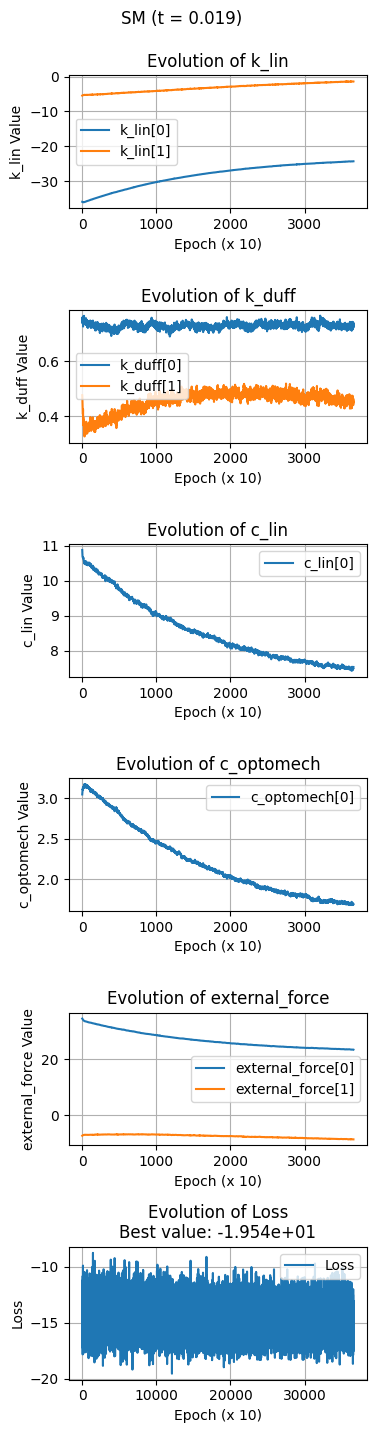

Optimization for time 0.02310129700083164
Epoch 0 - Loss: -9.1476
Epoch 100 - Loss: -11.7577
Epoch 200 - Loss: -10.5109
Epoch 300 - Loss: -12.4178
Epoch 400 - Loss: -11.1026
Epoch 500 - Loss: -13.7090
Epoch 600 - Loss: -12.2276
Epoch 700 - Loss: -15.0674
Epoch 800 - Loss: -11.5797
Epoch 900 - Loss: -12.0539
Epoch 1000 - Loss: -13.1468
Epoch 1100 - Loss: -12.9085
Epoch 1200 - Loss: -10.0870
Epoch 1300 - Loss: -10.9961
Epoch 1400 - Loss: -11.3690
Epoch 1500 - Loss: -10.5885
Epoch 1600 - Loss: -13.7496
Epoch 1700 - Loss: -11.7663
Epoch 1800 - Loss: -13.1224
Epoch 1900 - Loss: -13.7442
Epoch 2000 - Loss: -14.5209
Epoch 2100 - Loss: -13.9463
Epoch 2200 - Loss: -11.6086
Epoch 2300 - Loss: -11.8534
Epoch 2400 - Loss: -13.1435
Epoch 2500 - Loss: -10.1854
Epoch 2600 - Loss: -10.9055
Epoch 2700 - Loss: -12.7240
Epoch 2800 - Loss: -10.4327
Epoch 2900 - Loss: -12.4342
Epoch 3000 - Loss: -10.1264
Epoch 3100 - Loss: -11.6827
Epoch 3200 - Loss: -12.5908
Epoch 3300 - Loss: -13.2708
Epoch 3400 - Loss: 

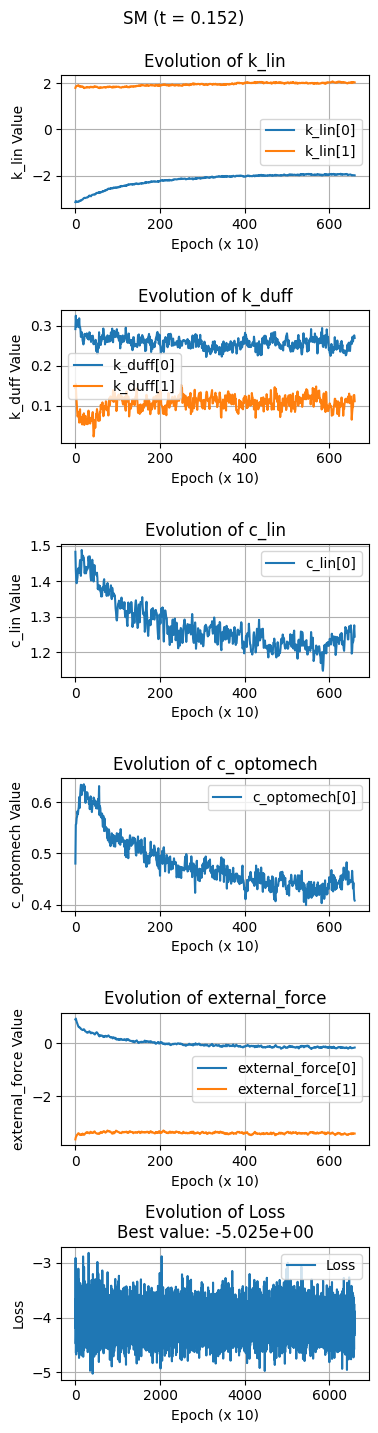

Optimization for time 0.1873817422860387
Epoch 0 - Loss: -3.2759
Epoch 100 - Loss: -3.5779
Epoch 200 - Loss: -3.9083
Epoch 300 - Loss: -4.3927
Epoch 400 - Loss: -3.7932
Epoch 500 - Loss: -4.0725
Epoch 600 - Loss: -4.2918
Epoch 700 - Loss: -4.0665
Epoch 800 - Loss: -3.9337
Epoch 900 - Loss: -3.9699
Epoch 1000 - Loss: -3.9379
Epoch 1100 - Loss: -3.5477
Epoch 1200 - Loss: -4.0878
Epoch 1300 - Loss: -3.8868
Epoch 1400 - Loss: -3.8135
Epoch 1500 - Loss: -3.4877
Epoch 1600 - Loss: -3.8056
Epoch 1700 - Loss: -4.1191
Epoch 1800 - Loss: -3.8575
Epoch 1900 - Loss: -3.7500
Epoch 2000 - Loss: -3.3211
Epoch 2100 - Loss: -3.6975
Epoch 2200 - Loss: -3.5372
Epoch 2300 - Loss: -3.9062
Epoch 2400 - Loss: -3.6137
Epoch 2500 - Loss: -3.8823
Epoch 2600 - Loss: -3.3787
Epoch 2700 - Loss: -3.6069
Epoch 2800 - Loss: -4.0239
Epoch 2900 - Loss: -3.5236
Epoch 3000 - Loss: -3.5138
Epoch 3100 - Loss: -4.1194
Epoch 3200 - Loss: -3.7016
Epoch 3300 - Loss: -4.0408
Epoch 3400 - Loss: -4.1878
Epoch 3500 - Loss: -3.8095

In [13]:
load_param_histories = False

if load_param_histories:
    # Load existing parameters
    params_history_all_t = jnp.load(f"{output_dir}/params_history.npy")
else:
    # Setup optimization parameters
    mask = jnp.ones(params_flattened_initial.shape[0])
    # mask = mask.at[0].set(1.)
    # mask = mask.at[1].set(1.)
    # mask = mask.at[2].set(1.)
    # mask = mask.at[3].set(0.)
    # mask = mask.at[-1].set(1.0)
    # mask = mask.at[-2].set(1.0)

    # Plotting parameters
    plot_steps = True  # Flag to control whether to plot during optimization
    plot_slice = 10     # Plot every nth step


    # Initialize storage for parameters at each time step
    params_history_all_t = []
    current_params = params_flattened_initial

    # Loop over time points
    for t_idx, t_curr in enumerate(forward_time_pts):
        print(f"Optimization for time {t_curr}")
        
        # Generate samples at current time
        key, subkey = jr.split(key)
        samples_t = sample_forward_process(
            t_curr, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_target, key=subkey
        )
        
        # Perform optimization starting from previous best parameters
        key, subkey = jr.split(key)
        
        params_history, loss_history = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            samples=samples_t,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=subkey,
            batch_size=batch_size,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            maximize=maximize,
            window_size=window_size,
            tolerance=tolerance,
            patience=patience,
            constraint_indices=constraint_indices
        )
        
        _, current_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
        
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    time = t_curr,
                    time_index = t_idx,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    slicing=10,
                    title=f"{training_method} (t = {t_curr:.3f})",
                    maximize=maximize,
                    labels_on=True,
                    save_fig=False,
                    path=output_dir,
                    param_names=params_names
                )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    jnp.save(f"{output_dir}/params_history.npy", params_history_all_t)


### Smoothen and interpolate parameter evolution

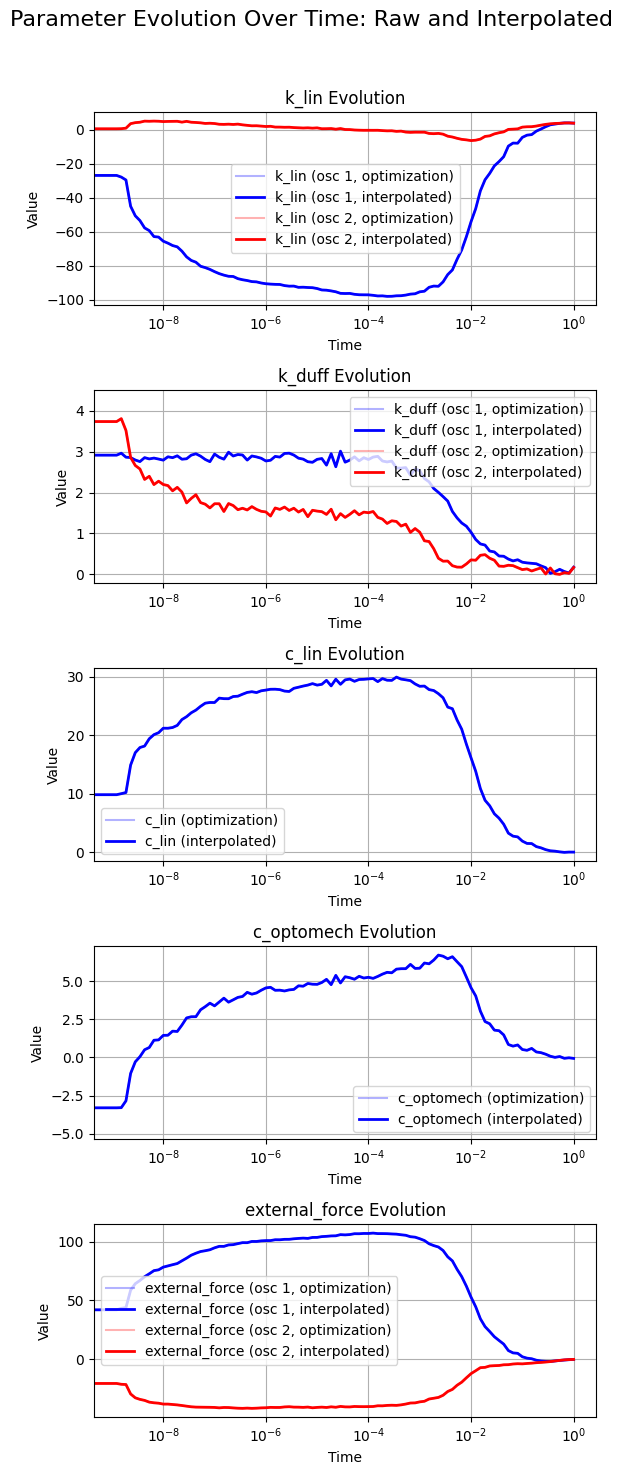

In [14]:
use_smoothed_params = False
if use_smoothed_params:
    # First smooth the parameters
    smoothed_params = smooth_parameters(params_history_all_t, window_lengths = [10, 10, 10, 10, 10, 10, 10, 10], poly_orders = [3, 3, 3, 3, 3, 3, 3, 3])
    # Get interpolator function
    params_interpolator = interpolate_parameters(smoothed_params, forward_time_pts)
else:
    # Get interpolator function
    params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0],forward_time_pts[-1],200)
# interpolated_params = interpolate_parameters(smoothed_params, forward_time_pts, time_dense)
interpolated_params = params_interpolator(time_eval)


plot_parameter_as_fn_of_time(params_names, forward_time_pts,forward_time_pts, params_history_all_t, params_interpolator, unflatten, N_osc) 

# Sampling via reverse SDE

In [15]:
forward_params = jnp.zeros_like(params_flattened_initial)
forward_params = forward_params.at[0:k_lin_0.shape[0]].set(1.)
params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - 1/sigma_forward**2 * forward_params
# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True)

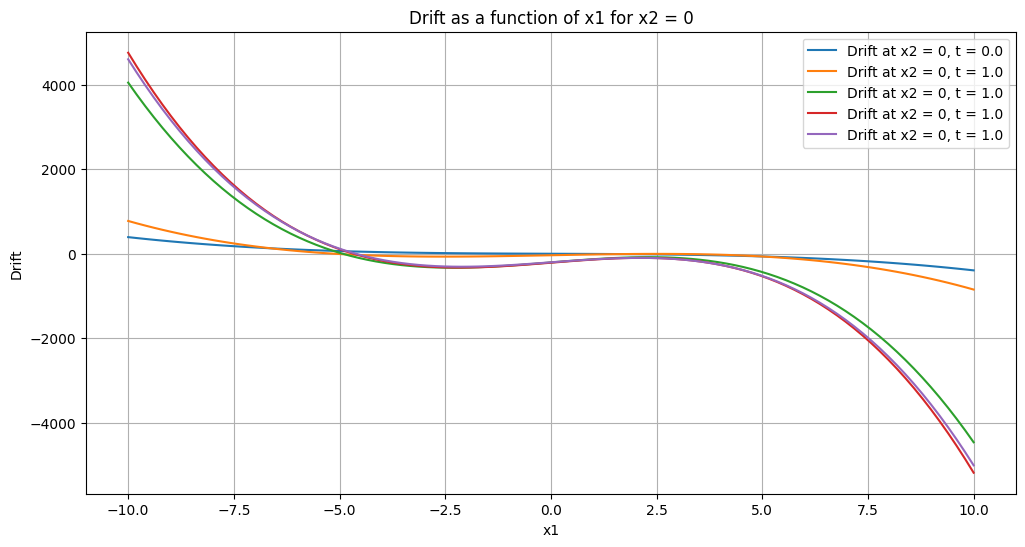

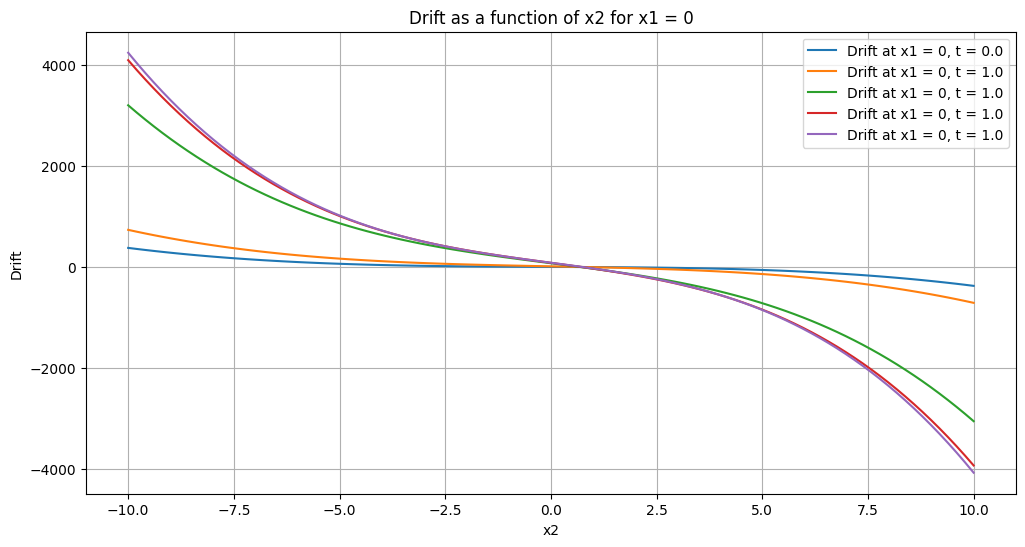

In [16]:
# Define filename for saving/loading parameters
n_time_steps = 5
time_steps = t_forward - jnp.exp(jnp.linspace(jnp.log(t_forward), jnp.log(1e-6), n_time_steps))


# Plot drift as a function of x1 for x2 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x1 = [drift_fn(t, jnp.array([x1, 0]), args=())[0] for x1 in x_range]
    plt.plot(x_range, drift_x1, label=f'Drift at x2 = 0, t = {t:.1f}')

plt.xlabel('x1')
plt.ylabel('Drift')
plt.title('Drift as a function of x1 for x2 = 0')
plt.legend()
plt.grid(True)
plt.show()

# Plot drift as a function of x2 for x1 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x2 = [drift_fn(t, jnp.array([0, x2]), args=())[1] for x2 in x_range]
    plt.plot(x_range, drift_x2, label=f'Drift at x1 = 0, t = {t:.1f}')

plt.xlabel('x2')
plt.ylabel('Drift')
plt.title('Drift as a function of x2 for x1 = 0')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 10)
dt0 = ts[1] - ts[0]

# Generate multiple initial states
n_trajectories = 2000
key, subkey = jr.split(key)
initial_states = sample_forward_process(t_forward, n_trajectories, sigma_final=sigma_forward, D=1, samples0=samples_target, key=subkey)
# Sample initial conditions from N(0, I)
# n_trajectories = 1000  # or any other number of trajectories you need
# n_dimensions = 2  # assuming 2D, adjust as necessary
# key, subkey = jr.split(key)
# initial_states = jr.normal(subkey, (n_trajectories, n_dimensions))

# Generate a key for each initial condition
key, subkey = jr.split(key)
keys_brownian = jr.split(subkey, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn, 
        diffusion_fn, 
        init_state,
        key_b, 
        t0, 
        t1, 
        ts.shape[0], 
        dt0
    ),
    in_axes=(0, 0)
)


# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys  # Shape: (n_trajectories, n_timesteps, 2)
final_states = (all_trajectories[:, -1, :])  # Shape: (n_trajectories, 2)


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

Solution from reverse process probability distribution total (should be ≈ 1): 1.000000


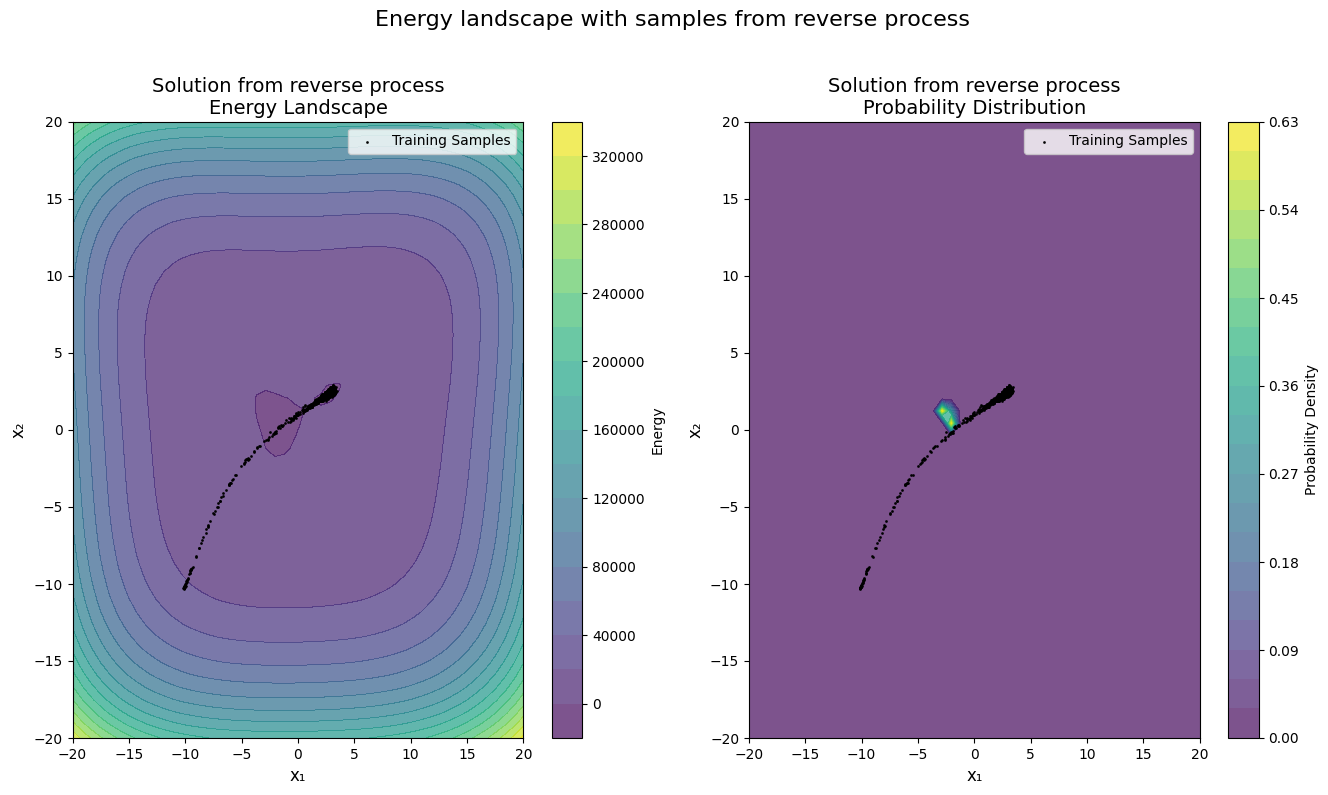

In [18]:
param_list = [params_interpolator(0.0)]
titles = ["Solution from reverse process"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=final_states,
    sample_stride=1,
    x1_range=(-20, 20),    
    x2_range=(-20, 20),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from reverse process"  
)

In [19]:
solve_time = 0.0
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(solve_time), N_osc,time_dependent_parms=False)
t0 = 0.0
t1 = 100 
ts = jnp.linspace(t0, t1, 1000)
dt0 = ts[1] - ts[0]
initial_state = jnp.array([-.0,0.])
key_equilibrium = jr.PRNGKey(111111)
solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,key_equilibrium, t0, t1, ts.shape[0], dt0)
sde_samples_direct = (solution_direct.ys) 


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

Solution from direct integration probability distribution total (should be ≈ 1): 1.000000


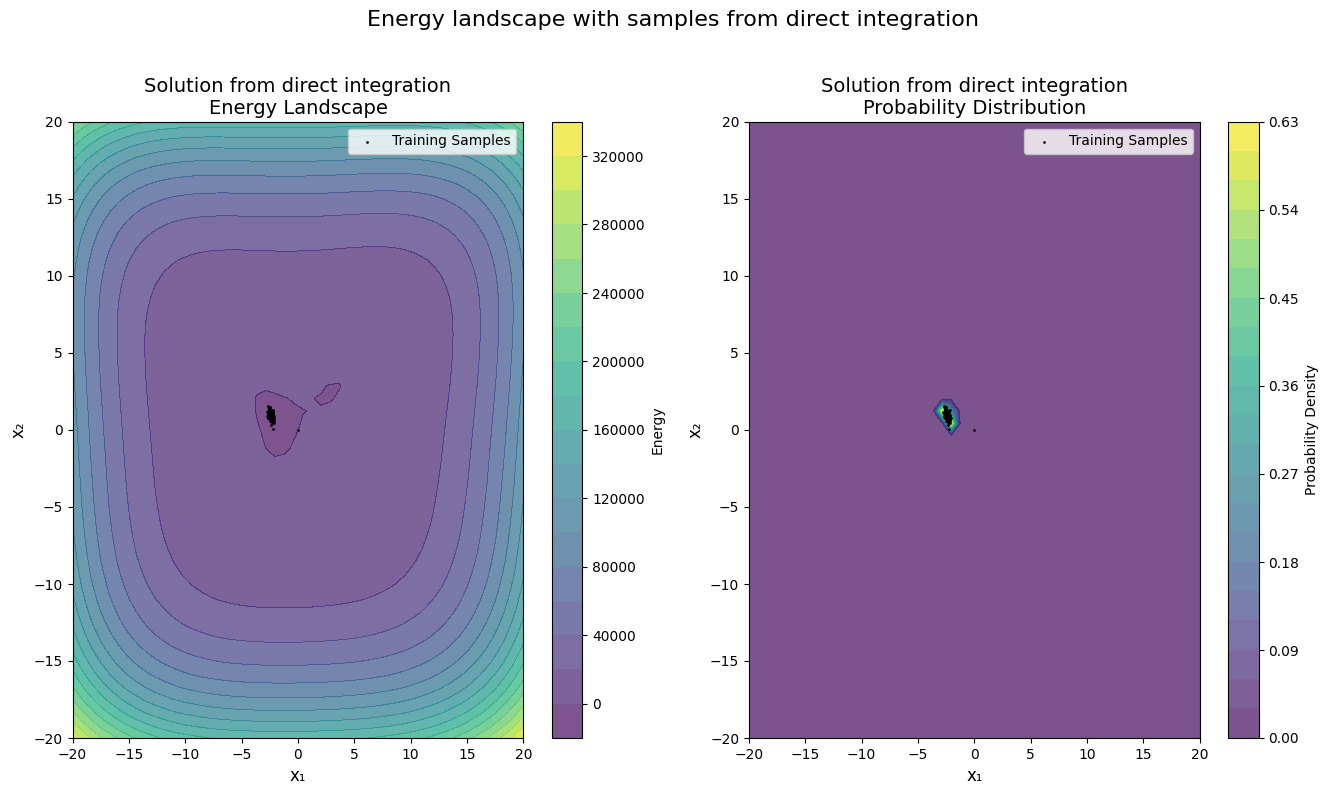

In [20]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from direct integration"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples_direct,
    sample_stride=10,
    x1_range=(-20, 20),    
    x2_range=(-20, 20),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from direct integration"  
)

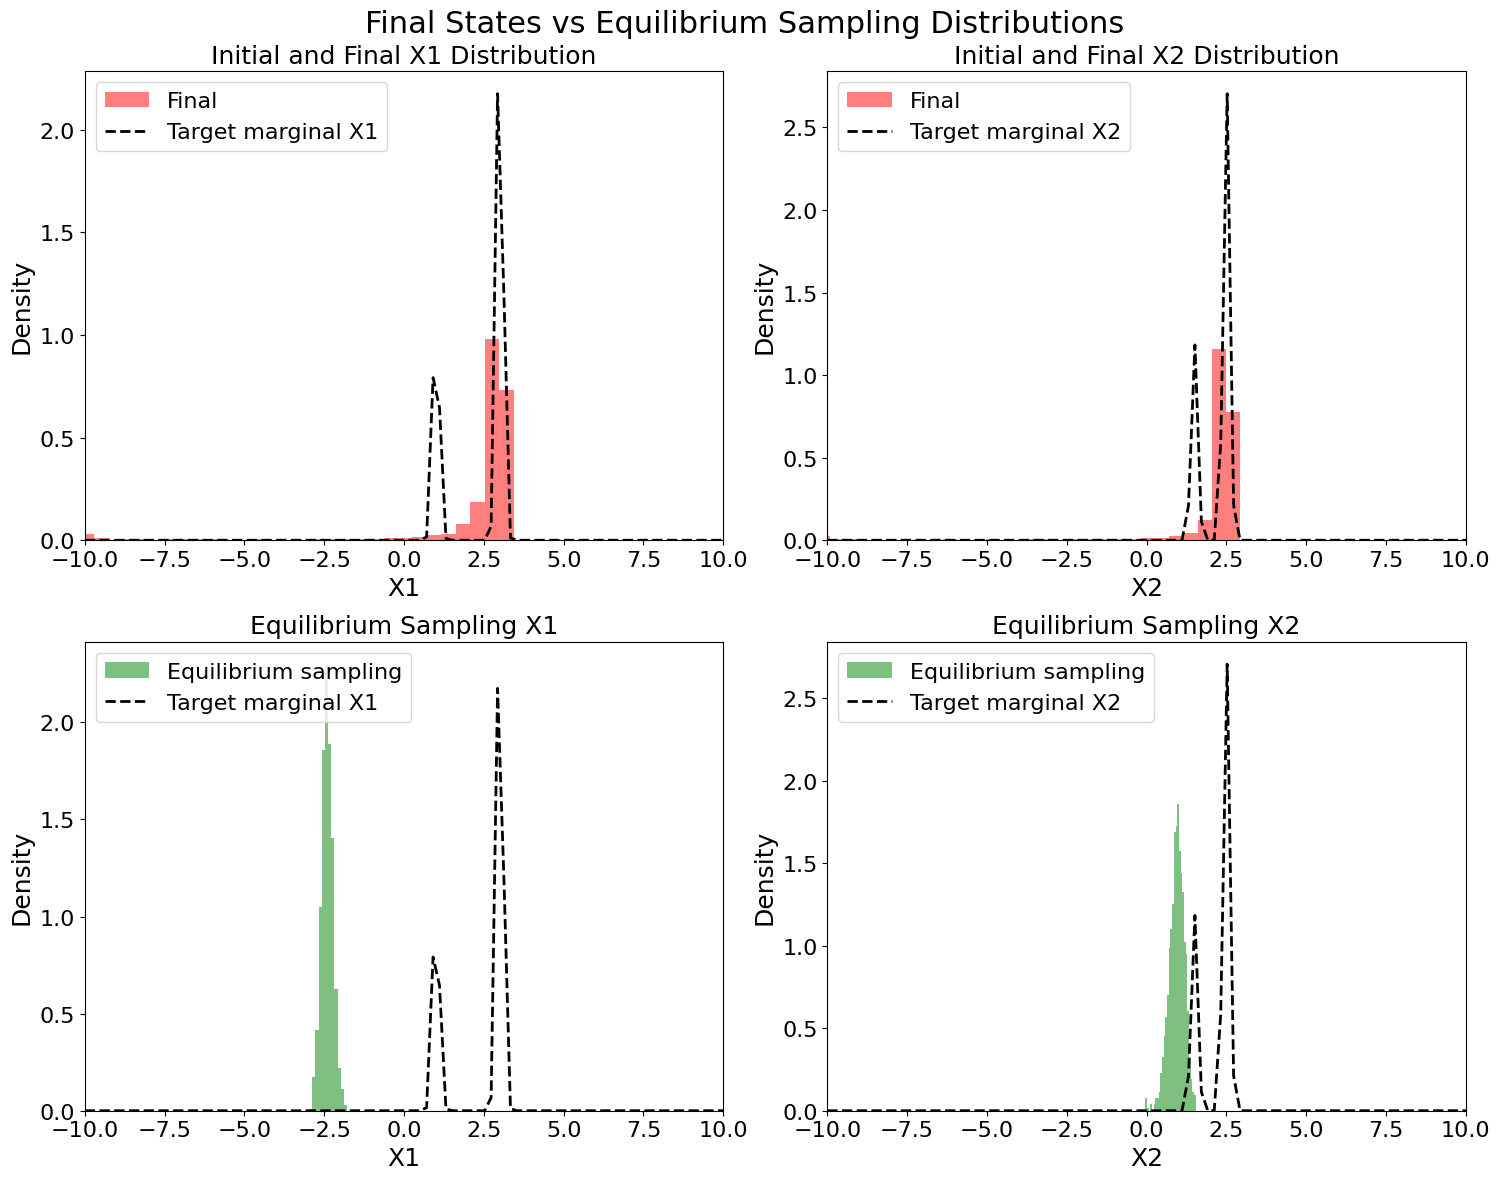

In [21]:
samples_rescaled = final_states * std_data+ mean_data
sde_samples_direct_rescaled = sde_samples_direct * std_data + mean_data

# Set font sizes
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

# Create 2x2 subplot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Final States vs Equilibrium Sampling Distributions', fontsize=BIGGER_SIZE)

# Top row: Initial and Final states
ax1.hist(samples_rescaled[:, 0], bins=30, alpha=0.5, density=True, label='Final', color='red')
ax2.hist(samples_rescaled[:, 1], bins=30, alpha=0.5, density=True, label='Final', color='red')

# Bottom row: Equilibrium sampling in green
ax3.hist(sde_samples_direct_rescaled[:, 0], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')
ax4.hist(sde_samples_direct_rescaled[:, 1], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')


# Plot marginals for each subplot separately with correct dimension
for ax, dim in [(ax1, 0), (ax2, 1), (ax3, 0), (ax4, 1)]:
    marginal = jnp.zeros_like(x_range)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x_range - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax.plot(x_range, marginal, '--k', linewidth=2, label=f'Target marginal {["X1", "X2"][dim]}')
    
    # Increase font sizes for tick labels
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE)

# Set titles and labels with increased font sizes
ax1.set_title('Initial and Final X1 Distribution', fontsize=MEDIUM_SIZE)
ax1.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax1.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax1.legend(fontsize=SMALL_SIZE)
ax1.set_xlim(x_range.min(),x_range.max())

ax2.set_title('Initial and Final X2 Distribution', fontsize=MEDIUM_SIZE)
ax2.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax2.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax2.legend(fontsize=SMALL_SIZE)
ax2.set_xlim(x_range.min(),x_range.max())


ax3.set_title('Equilibrium Sampling X1', fontsize=MEDIUM_SIZE)
ax3.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax3.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax3.legend(fontsize=SMALL_SIZE)
ax3.set_xlim(x_range.min(),x_range.max())

ax4.set_title('Equilibrium Sampling X2', fontsize=MEDIUM_SIZE)
ax4.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax4.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax4.legend(fontsize=SMALL_SIZE)
ax4.set_xlim(x_range.min(),x_range.max())


plt.tight_layout()
plt.show()